<a href="https://colab.research.google.com/github/johnriskquant/mml-data-science-notes/blob/main/calculus/2_layer_nn_impl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import required packages**




In [ ]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
np.random.seed(18)

**Explore what our data looks like**

In [ ]:
m = 2000
samples, labels = make_moons(n_samples = m, noise=0.1, random_state=18)
scaler = StandardScaler()
samples_scaled = scaler.fit_transform(samples)


The shape of X is: (2, 2000)
The shape of Y is: (1, 2000)
I have m = 2000 training examples!


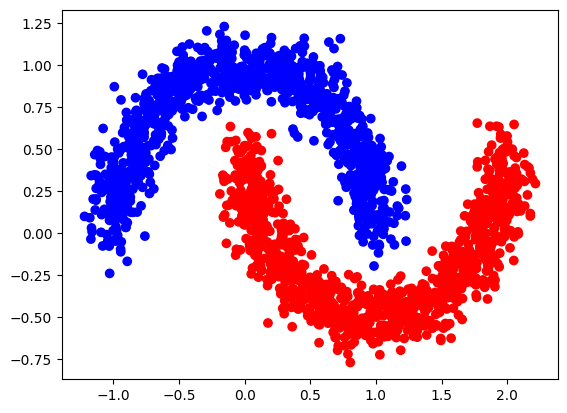

In [ ]:
X = np.transpose(samples)
Y = labels.reshape((1, m))

plt.scatter(X[0, :], X[1, :], c=Y, cmap=colors.ListedColormap(['blue', 'red']));

print ('The shape of X is: ' + str(X.shape))
print ('The shape of Y is: ' + str(Y.shape))
print ('I have m = %d training examples!' % (m))

Lets build a simple neural network that predicts color classification using the following workflow:


1. Define Structure: Number of input units, hidden layers, and output units.


1.   Define Structure: Number of input units, hidden layers, and output units.
2.   Initialize Parameters: Set weights to random small values and biases to zero.
3.   Training Loop:
*    Forward Propagation: Calculate the network's predictions.
*    Backward Propagation: Calculate gradients (the required corrections).
*    Update Parameters: Nudge weights and biases using the learning rate.
5. Inference: Make predictions on unseen data.





In [ ]:
def sigmoid(z: float)->float:
  return 1/(1+np.exp(-z))

**Defining the Neural Network Structure**


In [ ]:
def layer_sizes(X: np.ndarray, y:np.ndarray)->tuple:
  """
  Arguments:
  X -- input dataset of shape (input size, number of examples)
  Y -- labels of shape (output size, number of examples)

  Returns:
  n_x -- the size of the input layer
  n_h -- the size of the hidden layer
  n_y -- the size of the output layer
  """
  n_x = X.shape[0]
  n_h = 2
  n_y = y.shape[0]

  return n_x, n_h, n_y


In [ ]:
(n_x, n_h, n_y) = layer_sizes(X, Y)
print("The size of the input layer is: n_x = " + str(n_x))
print("The size of the hidden layer is: n_h = " + str(n_h))
print("The size of the output layer is: n_y = " + str(n_y))

The size of the input layer is: n_x = 2
The size of the hidden layer is: n_h = 2
The size of the output layer is: n_y = 1


**Initialize the Model's Parameters**

In [ ]:
def initialize_parameters(n_x:int, n_h:int,n_y:int) ->dict:
    """
    Argument:
    n_x -- size of the input layer
    n_h -- size of the hidden layer
    n_y -- size of the output layer

    Returns:
    params -- python dictionary containing your parameters:
                    W1 -- weight matrix of shape (n_h, n_x)
                    b1 -- bias vector of shape (n_h, 1)
                    W2 -- weight matrix of shape (n_y, n_h)
                    b2 -- bias vector of shape (n_y, 1)
    """
    W1 = np.random.randn(n_h,n_x) * 0.02
    b1 = np.zeros((n_h,1))
    W2 = np.random.randn(n_y, n_h) * 0.02
    b2 = np.zeros((n_y,1))
    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}
    return parameters

In [ ]:
parameters = initialize_parameters(n_x,n_h,n_y)
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

W1 = [[ 0.04134094 -0.00580648]
 [ 0.0120273  -0.01129054]]
b1 = [[0.]
 [0.]]
W2 = [[-0.02335903 -0.02044004]]
b2 = [[0.]]


**Entering the training loop**

In [ ]:
def forward_prop(X:np.ndarray, parameters:dict)->tuple:
  """
  Argument:
  X -- input data of size (n_x, m)
  parameters -- python dictionary containing your parameters (output of initialization function)

  Returns:
  A2 -- the sigmoid output of the second activation
  cache -- python dictionary containing Z1, A1, Z2, A2
  (that simplifies the calculations in the back propagation step)
  """
  # Retrieve each parameter from the dictionary "parameters".
    ### START CODE HERE ### (~ 4 lines of code)
  W1 = parameters['W1']
  b1 = parameters['b1']
  W2 = parameters['W2']
  b2 = parameters['b2']

  # Implement forward propagation to calculate A2.
  Z1 = np.dot(W1, X) + b1
  A1 = sigmoid(Z1)
  Z2 = np.dot(W2, A1) + b2
  A2 = sigmoid(Z2)

  assert(A2.shape == (n_y, X.shape[1]))

  cache = {"Z1": Z1,
             "A1": A1,
             "Z2": Z2,
             "A2": A2}

  return A2, cache


In [ ]:
A2, cache = forward_prop(X, parameters)

print(A2)

[[0.49452913 0.49450564 0.49459656 ... 0.49452412 0.49449262 0.49447946]]


Define a cost function $(8)$ which will be used to train the model:

$$\mathcal{L}\left(W, b\right)  = \frac{1}{m}\sum_{i=1}^{m}  \large\left(\small - y^{(i)}\log\left(a^{(i)}\right) - (1-y^{(i)})\log\left(1- a^{(i)}\right)  \large  \right) \small.$$

In [ ]:
def compute_cost(A2:np.ndarray, Y:np.ndarray)->float:
    """
    Computes the cost function as a log loss

    Arguments:
    A2 -- The output of the neural network of shape (1, number of examples)
    Y -- "true" labels vector of shape (1, number of examples)

    Returns:
    cost -- log loss
    """

    m = Y.shape[1]
    log_loss = (-Y* np.log(A2)) - ((1 - Y)*np.log(1-A2))
    cost = np.sum(log_loss)/m

    assert(isinstance(cost, float))

    return cost

In [ ]:
print("cost = " + str(compute_cost(A2, Y)))

cost = 0.6933008240014208


Calculate partial derivatives as shown in $(15)$:

\begin{align}
\frac{\partial \mathcal{L} }{ \partial W^{[2]} } &=
\frac{1}{m}\left(A^{[2]}-Y\right)\left(A^{[1]}\right)^T,\\
\frac{\partial \mathcal{L} }{ \partial b^{[2]} } &=
\frac{1}{m}\left(A^{[2]}-Y\right)\mathbf{1},\\
\frac{\partial \mathcal{L} }{ \partial W^{[1]}} &= \frac{1}{m}\left(\left(W^{[2]}\right)^T \left(A^{[2]} - Y\right)\cdot \left(A^{[1]}\cdot\left(1-A^{[1]}\right)\right)\right)X^T,\\
\frac{\partial \mathcal{L} }{ \partial b^{[1]}} &= \frac{1}{m}\left(\left(W^{[2]}\right)^T \left(A^{[2]} - Y\right)\cdot \left(A^{[1]}\cdot\left(1-A^{[1]}\right)\right)\right)\mathbf{1}.\\
\end{align}

In [ ]:
def backward_prop(parameters:dict, cache:dict, X: np.ndarray, Y:np.ndarray)-> dict:

  """
  Implements the backward propagation, calculating gradients

  Arguments:
  parameters -- python dictionary containing our parameters
  cache -- python dictionary containing Z1, A1, Z2, A2
  X -- input data of shape (n_x, number of examples)
  Y -- "true" labels vector of shape (n_y, number of examples)

  Returns:
  gradients -- python dictionary containing gradients with respect to different parameters
  """
  m = X.shape[1]

  # First, retrieve W from the dictionary "parameters".
  W1 = parameters["W1"]
  W2 = parameters["W2"]

  # Retrieve also A1 and A2 from dictionary "cache".
  A1 = cache["A1"]
  A2 = cache["A2"]

  # Backward propagation: calculate partial derivatives denoted as dW1, db1, dW2, db2 for simplicity.
  dZ2 = A2 - Y
  dW2 = 1/m * np.dot(dZ2, A1.T)
  db2 = 1/m * np.sum(dZ2, axis = 1, keepdims = True)
  dZ1 = np.dot(W2.T, dZ2) * A1 * (1 - A1)
  dW1 = 1/m * np.dot(dZ1, X.T)
  db1 = 1/m * np.sum(dZ1, axis = 1, keepdims = True)

  gradients = {"dW1": dW1,
            "db1": db1,
            "dW2": dW2,
            "db2": db2}

  return gradients

In [ ]:
gradients = backward_prop(parameters, cache, X, Y)

print("dW1 = " + str(gradients["dW1"]))
print("db1 = " + str(gradients["db1"]))
print("dW2 = " + str(gradients["dW2"]))
print("db2 = " + str(gradients["db2"]))

dW1 = [[ 0.0014689  -0.00111299]
 [ 0.00128663 -0.00097406]]
db1 = [[3.15062361e-05]
 [2.80971141e-05]]
dW2 = [[-0.00563182 -0.00404872]]
db2 = [[-0.00550704]]


Implement `update_parameters()`.

**Instructions**:
- Update parameters as shown in $(9)$ (section [2.3](#2.3)):
\begin{align}
W^{[1]} &= W^{[1]} - \alpha \frac{\partial \mathcal{L} }{ \partial W^{[1]} },\\
b^{[1]} &= b^{[1]} - \alpha \frac{\partial \mathcal{L} }{ \partial b^{[1]} },\\
W^{[2]} &= W^{[2]} - \alpha \frac{\partial \mathcal{L} }{ \partial W^{[2]} },\\
b^{[2]} &= b^{[2]} - \alpha \frac{\partial \mathcal{L} }{ \partial b^{[2]} }.\\
\end{align}

In [ ]:
def update_parameters(parameters, gradients, learning_rate=1.2, optimizer="gd", v=None, s=None, t=2):
    """
    Updates parameters using the selected optimization algorithm

    Arguments:
    parameters -- python dictionary containing parameters
    gradients -- python dictionary containing gradients
    learning_rate -- learning rate for gradient descent
    optimizer -- "gd" for standard gradient descent, or "adam"
    v, s, t -- Adam specific memory dictionaries and timestep

    Returns:
    parameters -- python dictionary containing updated parameters
    """
    # Retrieve each parameter from the dictionary "parameters"
    W1 = parameters['W1']
    b1 = parameters['b1']
    W2 = parameters['W2']
    b2 = parameters['b2']

    # Retrieve each gradient from the dictionary "gradients"
    dW1 = gradients['dW1']
    db1 = gradients['db1']
    dW2 = gradients['dW2']
    db2 = gradients['db2']

    if optimizer == "gd":
        # Standard Gradient Descent update rule
        W1 = W1 - learning_rate * dW1
        b1 = b1 - learning_rate * db1
        W2 = W2 - learning_rate * dW2
        b2 = b2 - learning_rate * db2

    elif optimizer == "adam":
        # 1. Adam Momentum (First moment)
        v["dW1"] = 0.9 * v["dW1"] + 0.1 * dW1
        v["db1"] = 0.9 * v["db1"] + 0.1 * db1
        v["dW2"] = 0.9 * v["dW2"] + 0.1 * dW2
        v["db2"] = 0.9 * v["db2"] + 0.1 * db2

        # 2. Adam RMSprop (Second moment)
        s["dW1"] = 0.999 * s["dW1"] + 0.001 * np.square(dW1)
        s["db1"] = 0.999 * s["db1"] + 0.001 * np.square(db1)
        s["dW2"] = 0.999 * s["dW2"] + 0.001 * np.square(dW2)
        s["db2"] = 0.999 * s["db2"] + 0.001 * np.square(db2)

        # 3. Parameter Update (incorporating bias correction and epsilon)
        eps = 1e-8
        W1 = W1 - learning_rate * (v["dW1"] / (1 - 0.9**t)) / (np.sqrt(s["dW1"] / (1 - 0.999**t)) + eps)
        b1 = b1 - learning_rate * (v["db1"] / (1 - 0.9**t)) / (np.sqrt(s["db1"] / (1 - 0.999**t)) + eps)
        W2 = W2 - learning_rate * (v["dW2"] / (1 - 0.9**t)) / (np.sqrt(s["dW2"] / (1 - 0.999**t)) + eps)
        b2 = b2 - learning_rate * (v["db2"] / (1 - 0.9**t)) / (np.sqrt(s["db2"] / (1 - 0.999**t)) + eps)

    # Repack the updated parameters
    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}

    return parameters

In [ ]:
parameters_updated = update_parameters(parameters, gradients)

print("W1 updated = " + str(parameters_updated["W1"]))
print("b1 updated = " + str(parameters_updated["b1"]))
print("W2 updated = " + str(parameters_updated["W2"]))
print("b2 updated = " + str(parameters_updated["b2"]))

W1 updated = [[ 0.03957826 -0.0044709 ]
 [ 0.01048334 -0.01012166]]
b1 updated = [[-3.78074834e-05]
 [-3.37165369e-05]]
W2 updated = [[-0.01660085 -0.01558159]]
b2 updated = [[0.00660844]]


Build your neural network model in `nn_model()`.

In [ ]:
def nn_model(X, Y, n_h, num_iterations=10, learning_rate=1.2, print_cost=False):
    """
    Arguments:
    X -- dataset of shape (n_x, number of examples)
    Y -- labels of shape (n_y, number of examples)
    num_iterations -- number of iterations in the loop
    learning_rate -- learning rate parameter for gradient descent
    print_cost -- if True, print the cost every iteration

    Returns:
    parameters -- parameters learnt by the model. They can then be used to predict.
    """

    n_x = layer_sizes(X, Y)[0]
    n_y = layer_sizes(X, Y)[2]

    # Initialize parameters.
    ### START CODE HERE ### (~ 1 line of code)
    parameters = initialize_parameters(n_x, n_h, n_y)
    ### END CODE HERE ###

    # Loop.
    for i in range(0, num_iterations):

        ### START CODE HERE ### (~ 4 lines of code)
        # Forward propagation. Inputs: "X, parameters". Outputs: "A2, cache".
        A2, cache = forward_prop(X, parameters)

        # Cost function. Inputs: "A2, Y". Outputs: "cost".
        cost = compute_cost(A2, Y)

        # Backpropagation. Inputs: "parameters, cache, X, Y". Outputs: "grads".
        grads = backward_prop(parameters, cache, X, Y)

        # Gradient descent parameter update. Inputs: "parameters, grads, learning_rate". Outputs: "parameters".
        parameters = update_parameters(parameters, grads, learning_rate)
        ### END CODE HERE ###

        # Print the cost every iteration.
        if print_cost:
            print ("Cost after iteration %i: %f" %(i, cost))

    return parameters

In [ ]:
parameters = nn_model(X, Y, n_h=2, num_iterations=40000, learning_rate=5, print_cost=True)
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

W1 = parameters["W1"]
b1 = parameters["b1"]
W2 = parameters["W2"]
b2 = parameters["b2"]

In [ ]:
def predict(X, parameters):
    """
    Using the learned parameters, predicts a class for each example in X

    Arguments:
    parameters -- python dictionary containing your parameters
    X -- input data of size (n_x, m)

    Returns
    predictions -- vector of predictions of our model (blue: 0 / red: 1)
    """

    ### START CODE HERE ### (≈ 2 lines of code)
    A2, cache = forward_prop(X, parameters)
    predictions = A2 > 0.5
    ### END CODE HERE ###

    return predictions

Text(0.5, 1.0, 'Decision Boundary for hidden layer size 2')

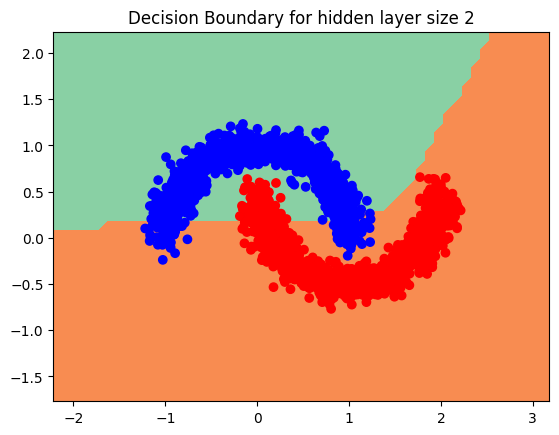

In [ ]:
def plot_decision_boundary(predict, parameters, X, Y):
    # Define bounds of the domain.
    min1, max1 = X[0, :].min()-1, X[0, :].max()+1
    min2, max2 = X[1, :].min()-1, X[1, :].max()+1
    # Define the x and y scale.
    x1grid = np.arange(min1, max1, 0.1)
    x2grid = np.arange(min2, max2, 0.1)
    # Create all of the lines and rows of the grid.
    xx, yy = np.meshgrid(x1grid, x2grid)
    # Flatten each grid to a vector.
    r1, r2 = xx.flatten(), yy.flatten()
    r1, r2 = r1.reshape((1, len(r1))), r2.reshape((1, len(r2)))
    # Vertical stack vectors to create x1,x2 input for the model.
    grid = np.vstack((r1,r2))
    # Make predictions for the grid.
    predictions = predict(grid, parameters)
    # Reshape the predictions back into a grid.
    zz = predictions.reshape(xx.shape)
    # Plot the grid of x, y and z values as a surface.
    plt.contourf(xx, yy, zz, cmap=plt.cm.Spectral.reversed())
    plt.scatter(X[0, :], X[1, :], c=Y, cmap=colors.ListedColormap(['blue', 'red']));

# Plot the decision boundary.
plot_decision_boundary(predict, parameters, X, Y)
plt.title("Decision Boundary for hidden layer size " + str(n_h))